# 甲狀腺結節合成資料生成

## 目標
將單一結節圖片中的結節裁切出來，貼到其他甲狀腺圖片上，產生多結節的合成資料。

## 流程
1. **資料分析** — 了解現有資料分佈
2. **建立供體池 (Donor Pool)** — 從單結節圖片中萃取結節
3. **建立受體池 (Recipient Pool)** — 選擇要貼上結節的底圖
4. **定義合成函數** — 結節萃取、增強、混合貼合
5. **測試單一合成** — 視覺化驗證單張合成效果
6. **批次生成** — 批量產生合成資料
7. **視覺化驗證** — 隨機抽樣確認品質
8. **儲存設定** — 輸出 data.yaml

**輸出目錄:** `yolo_data/synthesis_data_od/`

---
## 環境設定

In [35]:
import cv2
import numpy as np
import csv
import random
import shutil
import json
from pathlib import Path
from collections import defaultdict
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

random.seed(42)
np.random.seed(42)

# ─── 路徑設定 ───────────────────────────────────────────────
BASE_DIR  = Path('/Users/tony.tu/Desktop/戴承智慧/thyroid')
DATA_DIR  = BASE_DIR / 'yolo_data' / 'all_data_nodule_normal_cut_od'
CSV_DIR   = BASE_DIR / 'yolo_data' / 'all_csv_files'
version = "v6"
OUT_DIR   = BASE_DIR / 'yolo_data' / f'synthesis_data_od_{version}'

IMG_DIR   = DATA_DIR / 'images'
LBL_DIR   = DATA_DIR / 'labels'
MASK_DIR  = DATA_DIR / 'masks'
GLAND_SEG_DIR = BASE_DIR / 'yolo_data' / 'gland_seg_predictions'

# 建立輸出資料夾
(OUT_DIR / 'images').mkdir(parents=True, exist_ok=True)
(OUT_DIR / 'labels').mkdir(parents=True, exist_ok=True)

# ─── 合成參數 ────────────────────────────────────────────────
N_SYNTHETIC      = 30000   # 要生成的合成圖片數量
N_PASTE_RANGE    = (1, 3) # 每張圖貼幾個結節 (min, max)
SCALE_RANGE      = (0.6, 1.3) # 結節縮放範圍
BLEND_METHOD     = 'poisson'  # 'poisson' 或 'alpha'
MIN_NODULE_PX    = 15    # 最小結節尺寸 (像素)
OVERLAP_IOU_THR  = 0.05  # 允許的 IoU 上限
MAX_REUSE        = 10     # 同一張底圖最多可重複使用幾次（貼不同結節）

# ─── 目標資料集選擇 ──────────────────────────────────────────
# 決定最終輸出 dataset（recipient pool + train/val）涵蓋哪些來源
# 可選：'CG', 'TN3K', 'TN5000'（任意組合）
# 注意：donor pool 不受此設定影響，所有資料集都可作為供體來源
TARGET_DATASETS  = {'CG', 'TN5000', 'TN3K'}  # 修改此集合以選擇目標資料集

print('✓ 環境設定完成')
print(f'  影像數量 : {len(list(IMG_DIR.glob("*.png"))):,}')
print(f'  標籤數量 : {len(list(LBL_DIR.glob("*.txt"))):,}')
print(f'  遮罩數量 : {len(list(MASK_DIR.glob("*.png"))):,}')
print(f'  輸出目錄 : {OUT_DIR}')
print(f'  目標資料集: {sorted(TARGET_DATASETS)}')

✓ 環境設定完成
  影像數量 : 20,645
  標籤數量 : 20,645
  遮罩數量 : 20,645
  輸出目錄 : /Users/tony.tu/Desktop/戴承智慧/thyroid/yolo_data/synthesis_data_od_v6
  目標資料集: ['CG', 'TN3K', 'TN5000']


---
## Step 1: 資料分析

In [36]:
# 讀取 metadata CSV
csv_path = sorted(CSV_DIR.glob('combined_dataset_info*.csv'))[-1]
print(f'載入: {csv_path.name}\n')

metadata = []
with open(csv_path, newline='', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        # 確認影像檔案存在
        img_path = IMG_DIR / (row['file_name'] + '.png')
        if img_path.exists():
            row['img_path']  = img_path
            row['lbl_path']  = LBL_DIR  / (row['file_name'] + '.txt')
            row['mask_path'] = MASK_DIR  / (row['file_name'] + '.png')
            metadata.append(row)

print(f'找到對應影像的記錄: {len(metadata):,} 筆')

# 統計
from collections import Counter
type_counts  = Counter(r['nodule_type']  for r in metadata)
split_counts = Counter(r['train_or_test'] for r in metadata)
ds_counts    = Counter(r['dataset']       for r in metadata)

print(f"\n結節類型分佈:")
for k, v in type_counts.most_common():
    print(f"  {k:10s}: {v:6,} ({v/len(metadata)*100:.1f}%)")
print(f"\n訓練/測試分割:")
for k, v in split_counts.most_common():
    print(f"  {k:10s}: {v:6,}")
print(f"\n資料集來源:")
for k, v in ds_counts.most_common():
    print(f"  {k:10s}: {v:6,}")

載入: combined_dataset_info_v5.csv

找到對應影像的記錄: 20,645 筆

結節類型分佈:
  single    : 15,060 (72.9%)
  none      :  4,809 (23.3%)
  multiple  :    776 (3.8%)

訓練/測試分割:
  train     : 16,167
  test      :  4,478

資料集來源:
  CG        : 12,152
  TN5000    :  5,000
  TN3K      :  3,493


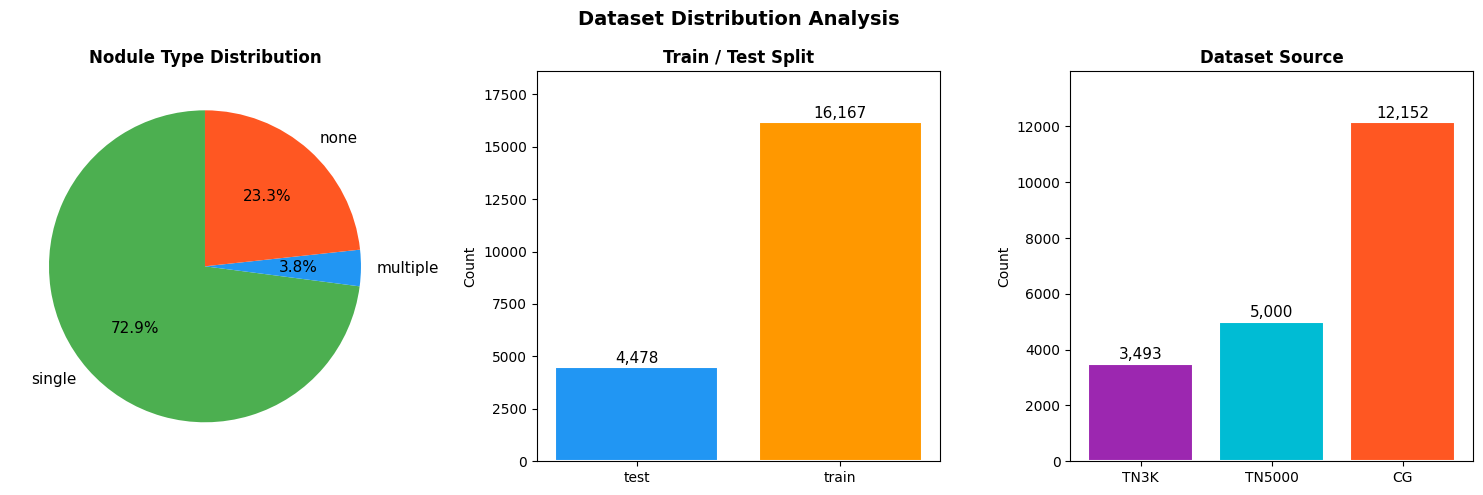

         'single'   nodule images = 15,060
Goal: boost multi-nodule samples via synthesis


In [37]:
# Visualize dataset distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Dataset Distribution Analysis', fontsize=14, fontweight='bold')

colors = ['#4CAF50', '#2196F3', '#FF5722']

# Nodule type
ax = axes[0]
labels = list(type_counts.keys())
sizes  = list(type_counts.values())
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct='%1.1f%%',
    colors=colors, startangle=90,
    textprops={'fontsize': 11})
ax.set_title('Nodule Type Distribution', fontweight='bold')

# Train / Test split
ax = axes[1]
ks = list(split_counts.keys())
vs = list(split_counts.values())
bars = ax.bar(ks, vs, color=['#2196F3', '#FF9800'], edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, vs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{v:,}', ha='center', va='bottom', fontsize=11)
ax.set_title('Train / Test Split', fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, max(vs) * 1.15)

# Dataset source
ax = axes[2]
ks2 = list(ds_counts.keys())
vs2 = list(ds_counts.values())
bars2 = ax.bar(ks2, vs2, color=['#9C27B0', '#00BCD4', '#FF5722'], edgecolor='white', linewidth=1.5)
for bar, v in zip(bars2, vs2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{v:,}', ha='center', va='bottom', fontsize=11)
ax.set_title('Dataset Source', fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, max(vs2) * 1.15)

plt.tight_layout()
plt.show()

print(f"Warning: 'multiple' nodule images = {type_counts.get('multiple', 0):,}")
print(f"         'single'   nodule images = {type_counts.get('single', 0):,}")
print(f"Goal: boost multi-nodule samples via synthesis")

---
## Step 2: 建立供體池 (Donor Pool)

從結節圖片中萃取結節區域，作為貼合用的供體。

**取樣策略：**
| 資料集 | 條件 | 策略 |
|--------|------|------|
| **CG** | single + multiple，train | **全部納入**（院內資料，域最接近） |
| TN3K | single，train | 隨機取樣 1500 張補充 |
| TN5000 | single，train | 隨機取樣 1500 張補充 |

CG 的 multiple 圖片也納入供體，`connectedComponentsWithStats` 會將每個連通域（每顆結節）分別萃取。

In [38]:
# ─── Helper functions ─────────────────────────────────────────

def load_yolo_labels(lbl_path):
    """Load YOLO OD labels, return list of dicts."""
    boxes = []
    if not Path(lbl_path).exists():
        return boxes
    with open(lbl_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                cls, cx, cy, w, h = map(float, parts)
                boxes.append({'cls': int(cls), 'cx': cx, 'cy': cy, 'w': w, 'h': h})
    return boxes


def yolo_to_pixel(box, img_w, img_h):
    """YOLO format → pixel coords (x1, y1, x2, y2)."""
    cx, cy, w, h = box['cx'], box['cy'], box['w'], box['h']
    x1 = int((cx - w / 2) * img_w)
    y1 = int((cy - h / 2) * img_h)
    x2 = int((cx + w / 2) * img_w)
    y2 = int((cy + h / 2) * img_h)
    return (x1, y1, x2, y2)


def pixel_to_yolo(x1, y1, x2, y2, img_w, img_h, cls=0):
    """Pixel coords → YOLO format string."""
    cx = ((x1 + x2) / 2) / img_w
    cy = ((y1 + y2) / 2) / img_h
    w  = (x2 - x1) / img_w
    h  = (y2 - y1) / img_h
    return f"{cls} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}"


def boxes_iou(b1, b2):
    """IoU of two bboxes (x1,y1,x2,y2)."""
    ix1 = max(b1[0], b2[0]);  iy1 = max(b1[1], b2[1])
    ix2 = min(b1[2], b2[2]);  iy2 = min(b1[3], b2[3])
    if ix2 <= ix1 or iy2 <= iy1:
        return 0.0
    inter = (ix2 - ix1) * (iy2 - iy1)
    area1 = (b1[2] - b1[0]) * (b1[3] - b1[1])
    area2 = (b2[2] - b2[0]) * (b2[3] - b2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0.0


def has_overlap(new_box, existing_boxes, thr=0.05):
    """True if new_box overlaps any existing box above IoU threshold."""
    return any(boxes_iou(new_box, ex) > thr for ex in existing_boxes)


def extract_nodule_crop(img_path, mask_path, lbl_path, pad_ratio=0.15):
    """
    Extract individual nodule crops from one image using the segmentation mask.
    Uses connectedComponentsWithStats so multiple nodules in one image are
    returned as separate crops.

    Returns list of dicts: {'img': crop_gray, 'mask': crop_mask_uint8}
    """
    img  = cv2.imread(str(img_path),  cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if img is None or mask is None:
        return []

    ih, iw = img.shape

    # Binarise mask — handles both 0/1 and 0/255 encoded masks
    bin_mask = (mask > 0).astype(np.uint8) * 255

    # Find connected components (each = one nodule)
    num_labels, labeled, stats, _ = cv2.connectedComponentsWithStats(bin_mask)

    crops = []
    for comp_id in range(1, num_labels):   # skip background (0)
        area = stats[comp_id, cv2.CC_STAT_AREA]
        if area < MIN_NODULE_PX ** 2:      # skip tiny noise components
            continue

        cx_s  = stats[comp_id, cv2.CC_STAT_LEFT]
        cy_s  = stats[comp_id, cv2.CC_STAT_TOP]
        cw    = stats[comp_id, cv2.CC_STAT_WIDTH]
        ch    = stats[comp_id, cv2.CC_STAT_HEIGHT]

        # Add padding around the nodule
        pad_x = max(5, int(cw * pad_ratio))
        pad_y = max(5, int(ch * pad_ratio))
        x1 = max(0,  cx_s - pad_x)
        y1 = max(0,  cy_s - pad_y)
        x2 = min(iw, cx_s + cw + pad_x)
        y2 = min(ih, cy_s + ch + pad_y)

        crop_img  = img[y1:y2, x1:x2]
        comp_mask = (labeled[y1:y2, x1:x2] == comp_id).astype(np.uint8) * 255

        if crop_img.size == 0 or comp_mask.sum() == 0:
            continue

        crops.append({'img': crop_img, 'mask': comp_mask})

    return crops


print('Helper functions loaded.')

Helper functions loaded.


In [39]:
# ─── 建立供體池 ───────────────────────────────────────────────
# 策略：
#   CG 資料：全部納入 (single + multiple)，因其為院內資料，分布最接近目標域
#   TN3K / TN5000：隨機取樣補充
CG_SAMPLE_OTHER = 10000  # 從 TN3K + TN5000 各自取樣的上限

# CG 訓練集 (single + multiple 都納入，connectedComponents 會分別萃取每顆結節)
cg_donors = [
    r for r in metadata
    if r['dataset'] == 'CG'
    and r['nodule_type'] in ('single', 'multiple')
    and r['train_or_test'] == 'train'
]

# TN3K / TN5000 訓練集 (只取 single)
tn3k_donors = [
    r for r in metadata
    if r['dataset'] == 'TN3K'
    and r['nodule_type'] == 'single'
    and r['train_or_test'] == 'train'
]
tn5k_donors = [
    r for r in metadata
    if r['dataset'] == 'TN5000'
    and r['nodule_type'] == 'single'
    and r['train_or_test'] == 'train'
]

sampled_tn3k = random.sample(tn3k_donors, min(CG_SAMPLE_OTHER, len(tn3k_donors)))
sampled_tn5k = random.sample(tn5k_donors, min(CG_SAMPLE_OTHER, len(tn5k_donors)))

sampled_donors = cg_donors + sampled_tn3k + sampled_tn5k
random.shuffle(sampled_donors)

print('建立供體池:')
print(f'  CG (single+multiple, 全納入): {len(cg_donors):,} 張')
print(f'  TN3K (single, 取樣)         : {len(sampled_tn3k):,} 張')
print(f'  TN5000 (single, 取樣)        : {len(sampled_tn5k):,} 張')
print(f'  合計                         : {len(sampled_donors):,} 張')

donor_crops = []
for r in tqdm(sampled_donors, desc='萃取結節'):
    if not r['mask_path'].exists():
        continue
    crops = extract_nodule_crop(r['img_path'], r['mask_path'], r['lbl_path'])
    donor_crops.extend(crops)

print(f'\n✓ 供體結節區塊共計: {len(donor_crops):,} 個')

建立供體池:
  CG (single+multiple, 全納入): 5,899 張
  TN3K (single, 取樣)         : 2,636 張
  TN5000 (single, 取樣)        : 3,500 張
  合計                         : 12,035 張


萃取結節:   0%|          | 0/12035 [00:00<?, ?it/s]


✓ 供體結節區塊共計: 13,347 個


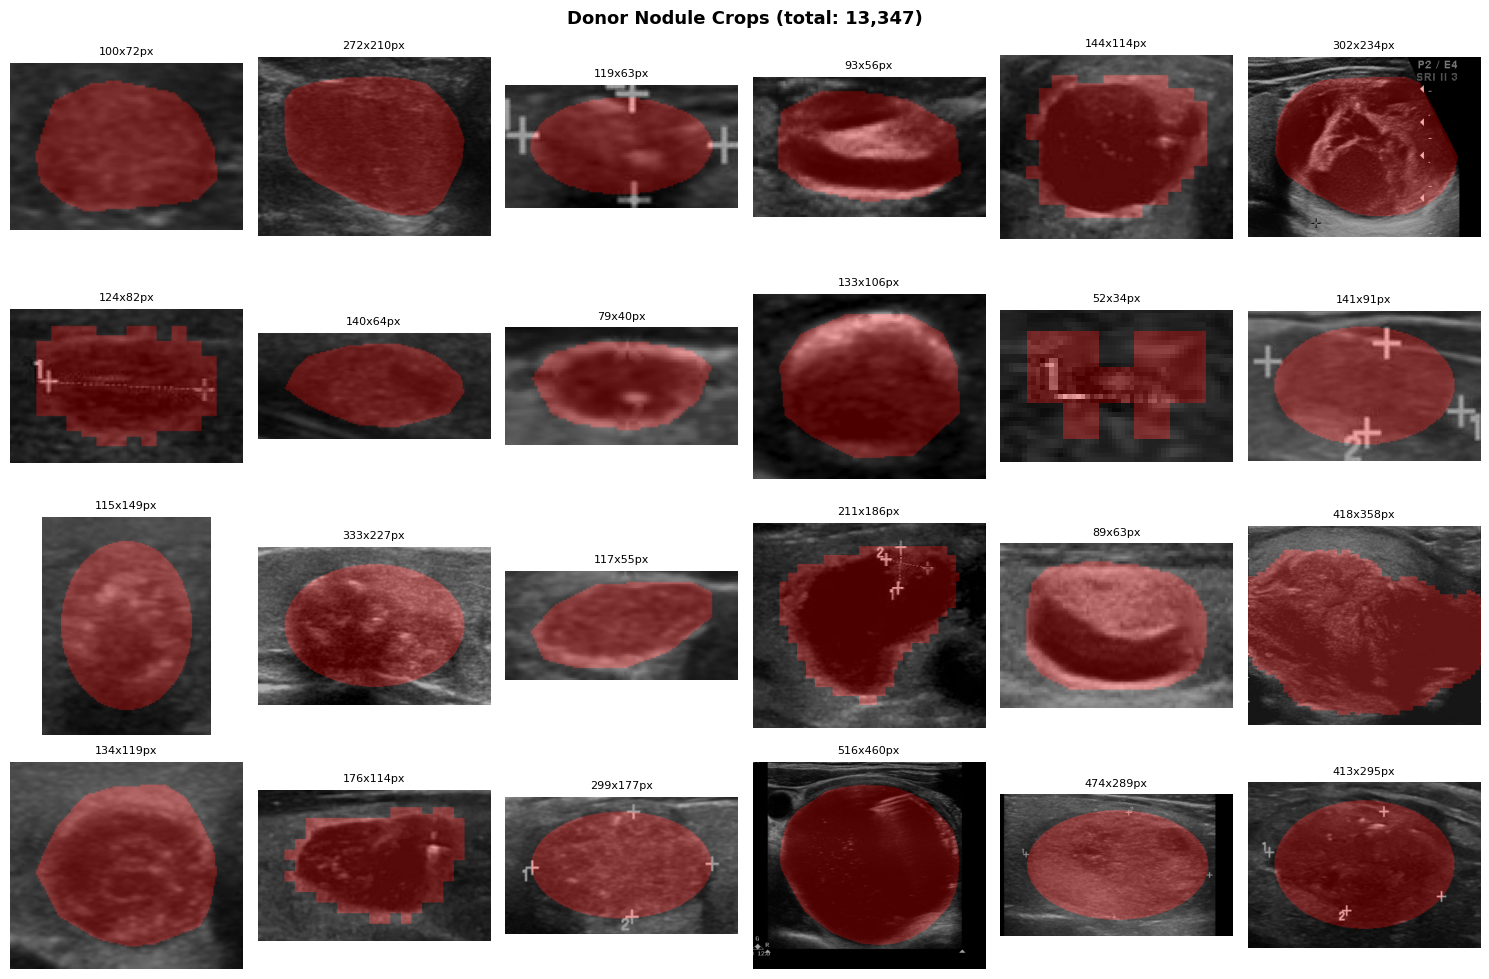

Red overlay = nodule mask region


In [40]:
# Visualize donor nodule crops
n_show = 24
sample_crops = random.sample(donor_crops, min(n_show, len(donor_crops)))

fig, axes = plt.subplots(4, 6, figsize=(15, 10))
fig.suptitle(f'Donor Nodule Crops (total: {len(donor_crops):,})', fontsize=13, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    if idx < len(sample_crops):
        crop = sample_crops[idx]
        h, w = crop['img'].shape

        overlay = cv2.cvtColor(crop['img'], cv2.COLOR_GRAY2BGR)
        mask_colored = np.zeros_like(overlay)
        mask_colored[:, :, 2] = crop['mask']  # red mask overlay
        overlay = cv2.addWeighted(overlay, 0.7, mask_colored, 0.3, 0)

        ax.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        ax.set_title(f'{w}x{h}px', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()
print('Red overlay = nodule mask region')

---
## Step 3: 建立受體池 (Recipient Pool)

受體圖片為貼合結節的底圖，只選**訓練集的單結節圖片**。

> 目標是合成**多結節**圖片，底圖必須已有至少 1 顆結節，貼上後才能形成多結節組合。

In [41]:
# Recipient pool: only single-nodule training images from TARGET_DATASETS
# Goal is multi-nodule synthesis, so the base image must already have >= 1 nodule
# Note: donor pool is not filtered — all datasets contribute as donors
recipient_records = [
    r for r in metadata
    if r['nodule_type'] == 'single'
    and r['train_or_test'] == 'train'
    and r['dataset'] in TARGET_DATASETS
]
print(f'Recipient pool: {len(recipient_records):,} images (single-nodule only)')
print(f'  Target datasets: {sorted(TARGET_DATASETS)}')

from collections import Counter as _Ctr
ds_dist = _Ctr(r['dataset'] for r in recipient_records)
for ds, cnt in ds_dist.most_common():
    print(f'  {ds:10s}: {cnt:,}')


Recipient pool: 11,681 images (single-nodule only)
  Target datasets: ['CG', 'TN3K', 'TN5000']
  CG        : 5,545
  TN5000    : 3,500
  TN3K      : 2,636


---
## Step 4: Define Synthesis Functions

### Key techniques
- **`estimate_thyroid_mask`**: Otsu thresholding + largest connected component → valid placement region
- **`find_valid_position`**: rejects candidates where < 80% of the nodule bbox falls inside the thyroid mask, preventing out-of-thyroid placements
- **`augment_crop`**: random scale (0.6–1.3×) + horizontal flip
- **Poisson blending** (`cv2.seamlessClone MIXED_CLONE`) — primary method
- **Alpha blending** (Gaussian feather) — automatic fallback

In [42]:
def estimate_thyroid_mask(img, blur_ksize=25, seed_points=None, gland_seg_mask=None):
    """
    Estimate thyroid tissue region.

    Pipeline:
      1. CLAHE  — normalise brightness variation across the image
      2. Gaussian blur  — suppress speckle noise before thresholding
      3. Otsu threshold — binarise
      4. Opening (erode→dilate)  — remove small noise blobs
      5. Seed-based connected component — pick the component that contains
                                          a nodule centre (seed_points);
                                          fall back to largest if no seed
                                          lands in any component
      6. Fill holes  — flood-fill from border to recover interior dark areas
                       (vessels, nodules, shadows) that were wrongly excluded
      7. Morphological closing — smooth the boundary without expanding outward
      8. Slight erosion — pull the boundary inward so nodule placement
                          stays clearly within the gland (replaces the old
                          dilation that caused out-of-gland placements)

    Returns uint8 binary mask (255 = valid placement region).
    """
    # 1. CLAHE
    clahe   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(img)

    # 2. Gaussian blur
    blurred = cv2.GaussianBlur(enhanced, (blur_ksize, blur_ksize), 0)

    # 3. Otsu threshold
    _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 4. Opening: remove isolated noise (small bright dots / lines)
    open_k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    binary  = cv2.morphologyEx(binary, cv2.MORPH_OPEN, open_k, iterations=1)

    # 5. Pick component by seed (nodule centre), fall back to largest
    num_labels, labeled, stats, _ = cv2.connectedComponentsWithStats(binary)
    if num_labels <= 1:
        return np.ones_like(img, dtype=np.uint8) * 255
    areas       = [(stats[i, cv2.CC_STAT_AREA], i) for i in range(1, num_labels)]
    largest_idx = max(areas)[1]
    chosen_idx  = largest_idx          # default: largest
    if seed_points:
        for sx, sy in seed_points:
            sx, sy = int(sx), int(sy)
            if 0 <= sy < labeled.shape[0] and 0 <= sx < labeled.shape[1]:
                lbl = int(labeled[sy, sx])
                if lbl > 0:            # seed lands inside a foreground component
                    chosen_idx = lbl
                    break
    mask        = (labeled == chosen_idx).astype(np.uint8) * 255

    # 5b. Intersect with gland segmentation prediction
    if gland_seg_mask is not None:
        gland_bin = cv2.resize(gland_seg_mask, (mask.shape[1], mask.shape[0]),
                               interpolation=cv2.INTER_NEAREST)
        gland_bin = (gland_bin > 0).astype(np.uint8) * 255
        mask      = cv2.bitwise_and(mask, gland_bin)

    # 6. Fill holes: flood-fill background from all four corners, then invert
    h, w       = mask.shape
    flood_mask = np.zeros((h + 2, w + 2), dtype=np.uint8)
    filled     = mask.copy()
    for pt in [(0, 0), (0, w - 1), (h - 1, 0), (h - 1, w - 1)]:
        if filled[pt] == 0:
            cv2.floodFill(filled, flood_mask, (pt[1], pt[0]), 128)
    # pixels still 0 are interior holes — fill them
    mask = np.where(filled == 0, 255, mask).astype(np.uint8)

    # 7. Closing: smooth the contour (dilate then erode — net effect is near-zero expansion)
    close_k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (21, 21))
    mask    = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, close_k, iterations=1)

    # 8. Erosion: pull boundary inward so pasted nodules stay inside the gland
    erode_k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    mask    = cv2.erode(mask, erode_k, iterations=1)

    return mask


def augment_crop(crop, flip_only=False, scale_range=(0.6, 1.3)):
    """
    Augment a nodule crop with:
      - Random scale (unless flip_only)
      - Random horizontal flip (50%)
      - Random rotation ±30°
      - Random brightness/contrast adjustment
      - Random Gaussian noise
    """
    img  = crop['img'].copy()
    mask = crop['mask'].copy()

    # ── Scale ──────────────────────────────────────────────────
    if not flip_only:
        scale = random.uniform(*scale_range)
        h, w  = img.shape[:2]
        new_h = max(10, int(h * scale))
        new_w = max(10, int(w * scale))
        img  = cv2.resize(img,  (new_w, new_h), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (new_w, new_h), interpolation=cv2.INTER_NEAREST)

    # ── Horizontal flip ────────────────────────────────────────
    if random.random() < 0.5:
        img  = cv2.flip(img,  1)
        mask = cv2.flip(mask, 1)

    # ── Rotation ───────────────────────────────────────────────
    angle = random.uniform(-30, 30)
    h, w  = img.shape[:2]
    M     = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    img   = cv2.warpAffine(img,  M, (w, h), flags=cv2.INTER_LINEAR,
                            borderMode=cv2.BORDER_REFLECT_101)
    mask  = cv2.warpAffine(mask, M, (w, h), flags=cv2.INTER_NEAREST,
                            borderValue=0)

    # ── Brightness / contrast ──────────────────────────────────
    alpha = random.uniform(0.75, 1.25)   # contrast
    beta  = random.randint(-20, 20)       # brightness offset
    img   = np.clip(img.astype(np.float32) * alpha + beta, 0, 255).astype(np.uint8)

    # ── Gaussian noise ─────────────────────────────────────────
    noise_std = random.uniform(0, 12)
    if noise_std > 0:
        noise = np.random.normal(0, noise_std, img.shape).astype(np.float32)
        img   = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    return {'img': img, 'mask': mask}


def clamp_to_ref_size(aug, ref_w_px, ref_h_px, ratio_range=(0.5, 2.0)):
    """
    Resize aug so its bbox falls within ratio_range of the reference nodule size.
    Comparison is done on the longer side to avoid distortion.
    """
    nh, nw = aug['img'].shape[:2]
    ref_side  = max(ref_w_px, ref_h_px)
    crop_side = max(nw, nh)

    ratio = crop_side / ref_side
    if ratio_range[0] <= ratio <= ratio_range[1]:
        return aug  # already within range

    # Clamp
    target_ratio = np.clip(ratio, *ratio_range)
    scale  = target_ratio / ratio
    new_h  = max(10, int(nh * scale))
    new_w  = max(10, int(nw * scale))

    img  = cv2.resize(aug['img'],  (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    mask = cv2.resize(aug['mask'], (new_w, new_h), interpolation=cv2.INTER_NEAREST)
    return {'img': img, 'mask': mask}


def find_valid_position(nh, nw, img_h, img_w, existing_boxes,
                         thyroid_mask=None, coverage_thr=0.8,
                         max_tries=150, margin=10):
    """
    Find a placement where:
      1. Bbox is fully inside image.
      2. >= coverage_thr of bbox area is inside the thyroid mask.
      3. IoU with existing boxes < OVERLAP_IOU_THR.
    """
    for _ in range(max_tries):
        cy = random.randint(nh // 2 + margin, img_h - nh // 2 - margin)
        cx = random.randint(nw // 2 + margin, img_w - nw // 2 - margin)
        x1, y1 = cx - nw // 2, cy - nh // 2
        x2, y2 = x1 + nw,      y1 + nh
        if x1 < 0 or y1 < 0 or x2 > img_w or y2 > img_h:
            continue
        if thyroid_mask is not None:
            region   = thyroid_mask[y1:y2, x1:x2]
            coverage = region.sum() / (255.0 * (y2 - y1) * (x2 - x1))
            if coverage < coverage_thr:
                continue
        if not has_overlap((x1, y1, x2, y2), existing_boxes, OVERLAP_IOU_THR):
            return cy, cx, x1, y1, x2, y2
    return None


def paste_nodule_feather(target, nodule_info, cy, cx, feather_ksize=11):
    """Gaussian-feather alpha blend fallback."""
    result = target.astype(np.float32).copy()
    nimg   = nodule_info['img'].astype(np.float32)
    nmask  = nodule_info['mask']
    nh, nw = nimg.shape[:2]

    x1, y1 = cx - nw // 2, cy - nh // 2
    x2, y2 = x1 + nw, y1 + nh

    y1c, x1c = max(0, y1), max(0, x1)
    y2c, x2c = min(result.shape[0], y2), min(result.shape[1], x2)
    ny1, nx1 = y1c - y1, x1c - x1
    ny2, nx2 = ny1 + (y2c - y1c), nx1 + (x2c - x1c)

    if ny2 <= ny1 or nx2 <= nx1:
        return target

    alpha = cv2.GaussianBlur(
        nmask[ny1:ny2, nx1:nx2].astype(np.float32),
        (feather_ksize, feather_ksize), 0
    ) / 255.0

    result[y1c:y2c, x1c:x2c] = (
        alpha * nimg[ny1:ny2, nx1:nx2] +
        (1 - alpha) * result[y1c:y2c, x1c:x2c]
    )
    return np.clip(result, 0, 255).astype(np.uint8)


def paste_nodule(target, nodule_info, cy, cx,
                 use_poisson=True, feather_ksize=11):
    """
    Paste a nodule crop onto target using Poisson seamless cloning.

    Poisson blending solves the Laplacian equation so the pasted region
    matches the surrounding background gradients — eliminates hard edges
    and intensity jumps that occur with simple alpha-blend.

    Falls back to Gaussian feathering when:
      - use_poisson=False
      - seamlessClone raises an exception (e.g. mask too close to border)

    Parameters
    ----------
    target      : uint8 grayscale image (H x W)
    nodule_info : dict with 'img' (uint8 gray) and 'mask' (uint8 binary)
    cy, cx      : centre of placement in target coordinates
    use_poisson : use cv2.seamlessClone (NORMAL_CLONE)
    feather_ksize : kernel size for fallback Gaussian feathering
    """
    nimg  = nodule_info['img']
    nmask = nodule_info['mask']
    nh, nw = nimg.shape[:2]

    x1, y1 = cx - nw // 2, cy - nh // 2
    x2, y2 = x1 + nw, y1 + nh

    # Clamp crop window to image bounds
    y1c, x1c = max(0, y1), max(0, x1)
    y2c, x2c = min(target.shape[0], y2), min(target.shape[1], x2)
    ny1, nx1 = y1c - y1, x1c - x1
    ny2, nx2 = ny1 + (y2c - y1c), nx1 + (x2c - x1c)

    if ny2 <= ny1 or nx2 <= nx1:
        return target

    if use_poisson:
        try:
            # seamlessClone requires 3-channel uint8 images
            src_crop  = cv2.cvtColor(nimg[ny1:ny2, nx1:nx2], cv2.COLOR_GRAY2BGR)
            dst_bgr   = cv2.cvtColor(target, cv2.COLOR_GRAY2BGR)
            mask_crop = nmask[ny1:ny2, nx1:nx2]

            # Erode mask slightly so it never touches the crop border
            # (seamlessClone fails when foreground pixels are on the edge)
            kern = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
            mask_crop = cv2.erode(mask_crop, kern, iterations=1)

            if mask_crop.sum() == 0:
                raise ValueError("mask became empty after erosion")

            # Embed the small crop into a same-size canvas as the target
            canvas_src  = np.zeros_like(dst_bgr)
            canvas_mask = np.zeros(target.shape, dtype=np.uint8)
            canvas_src [y1c:y2c, x1c:x2c] = src_crop
            canvas_mask[y1c:y2c, x1c:x2c] = mask_crop

            center = (cx, cy)   # (x, y) convention for seamlessClone
            blended_bgr = cv2.seamlessClone(
                canvas_src, dst_bgr, canvas_mask,
                center, cv2.NORMAL_CLONE
            )
            return cv2.cvtColor(blended_bgr, cv2.COLOR_BGR2GRAY)

        except Exception:
            pass  # fall through to feathering

    # Feather fallback
    return paste_nodule_feather(target, nodule_info, cy, cx, feather_ksize)



def generate_synthetic(recipient_record, donor_crops,
                        n_paste_range=(1, 3),
                        scale_range=(0.6, 1.3),
                        size_ratio_range=(0.5, 2.0),
                        use_poisson=True):
    """
    Generate one synthetic multi-nodule image.
    Pasted nodules are constrained to size_ratio_range relative to the
    recipient's existing nodule (50%–200% by default).
    Returns (result_img, label_lines, added_boxes) or None.
    """
    img = cv2.imread(str(recipient_record['img_path']), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    ih, iw = img.shape
    lbls   = load_yolo_labels(recipient_record['lbl_path'])
    existing_boxes = [yolo_to_pixel(b, iw, ih) for b in lbls]
    label_lines    = [f"{b['cls']} {b['cx']:.6f} {b['cy']:.6f} {b['w']:.6f} {b['h']:.6f}" for b in lbls]

    # Reference size: use the largest existing nodule
    if lbls:
        ref = max(lbls, key=lambda b: b['w'] * b['h'])
        ref_w_px = ref['w'] * iw
        ref_h_px = ref['h'] * ih
    else:
        ref_w_px = ref_h_px = None

    # Use nodule centres as seeds so the mask grows from the nodule's component
    # Intersect with gland segmentation model prediction for extra accuracy
    seed_pts      = [(b['cx'] * iw, b['cy'] * ih) for b in lbls]
    gland_seg_path = GLAND_SEG_DIR / (recipient_record['img_path'].stem + '.png')
    gland_seg_mask = (cv2.imread(str(gland_seg_path), cv2.IMREAD_GRAYSCALE)
                      if gland_seg_path.exists() else None)
    thyroid_mask  = estimate_thyroid_mask(img, seed_points=seed_pts or None,
                                           gland_seg_mask=gland_seg_mask)

    n_paste     = random.randint(*n_paste_range)
    result      = img.copy()
    added_boxes = []

    for _ in range(n_paste):
        nodule = random.choice(donor_crops)

        # Full augmentation: scale + flip + rotation + brightness/contrast + noise
        aug = augment_crop(nodule, scale_range=scale_range)

        # Clamp to 50%–200% of the recipient's existing nodule
        if ref_w_px is not None:
            aug = clamp_to_ref_size(aug, ref_w_px, ref_h_px, size_ratio_range)

        nh, nw = aug['img'].shape[:2]
        if nh < MIN_NODULE_PX or nw < MIN_NODULE_PX:
            continue
        if nh >= ih - 30 or nw >= iw - 30:
            continue

        pos = find_valid_position(nh, nw, ih, iw,
                                   existing_boxes + added_boxes,
                                   thyroid_mask=thyroid_mask)
        if pos is None:
            continue

        cy, cx, x1, y1, x2, y2 = pos
        result = paste_nodule(result, aug, cy, cx, use_poisson=use_poisson)
        label_lines.append(pixel_to_yolo(x1, y1, x2, y2, iw, ih, cls=0))
        added_boxes.append((x1, y1, x2, y2))

    if not added_boxes:
        return None

    return result, label_lines, added_boxes


print('Synthesis functions loaded.')

Synthesis functions loaded.


---
## Step 5: 測試單一合成效果

在批次生成前，先視覺化驗證單張合成結果是否正確。

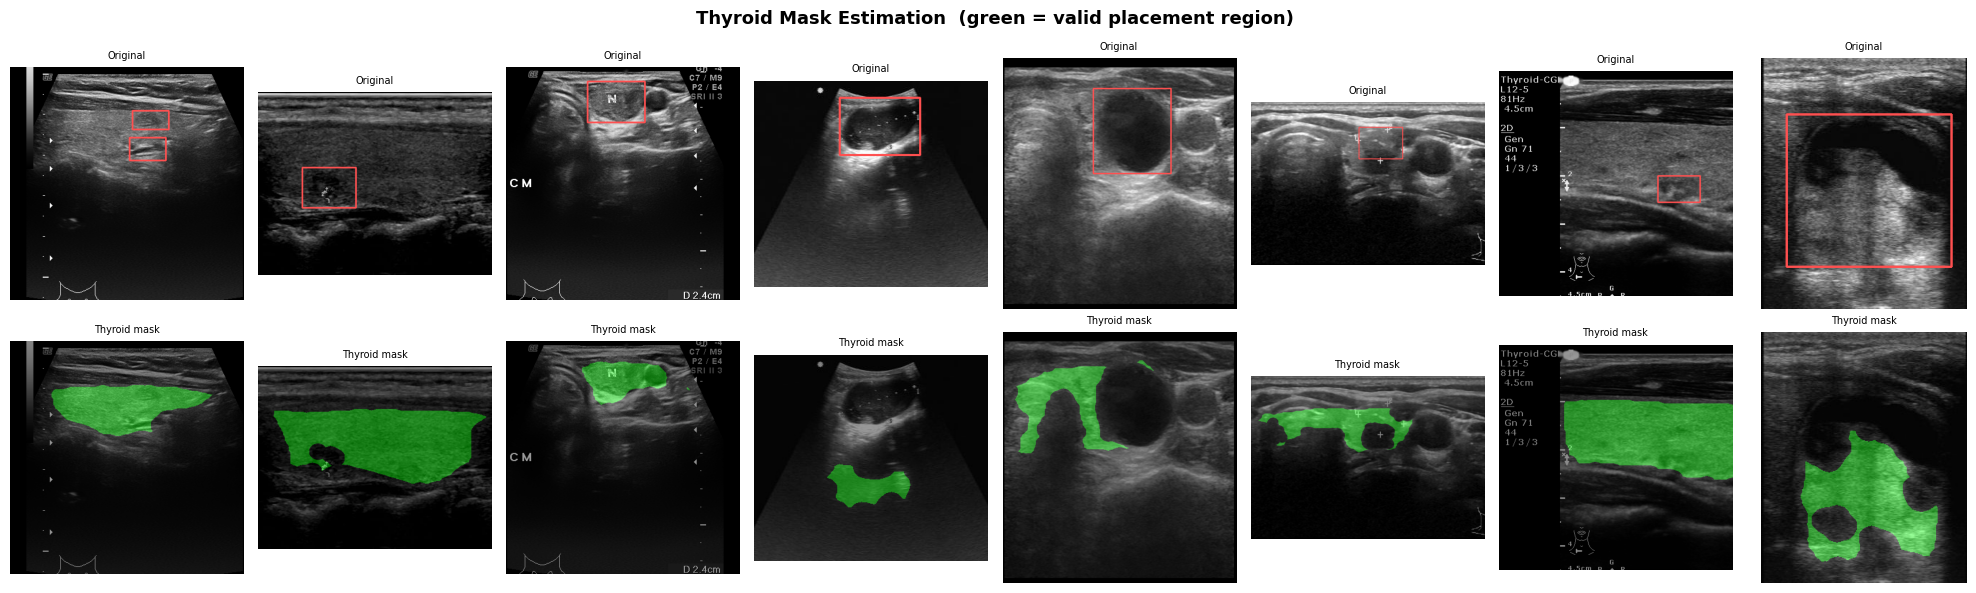

Green region = valid area for nodule placement


In [43]:
# Verify thyroid mask estimation on a few sample images
sample_verify = random.sample(recipient_records, 8)

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle('Thyroid Mask Estimation  (green = valid placement region)', fontsize=13, fontweight='bold')

for col, r in enumerate(sample_verify):
    img          = cv2.imread(str(r['img_path']), cv2.IMREAD_GRAYSCALE)
    lbls         = load_yolo_labels(r['lbl_path'])
    ih, iw       = img.shape
    seed_pts       = [(b['cx'] * iw, b['cy'] * ih) for b in lbls]
    gland_seg_path = GLAND_SEG_DIR / (r['img_path'].stem + '.png')
    gland_seg_mask = (cv2.imread(str(gland_seg_path), cv2.IMREAD_GRAYSCALE)
                      if gland_seg_path.exists() else None)
    thyroid_mask   = estimate_thyroid_mask(img, seed_points=seed_pts or None,
                                            gland_seg_mask=gland_seg_mask)

    # Row 0: original with nodule bbox
    disp = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    for b in lbls:
        x1, y1, x2, y2 = yolo_to_pixel(b, iw, ih)
        cv2.rectangle(disp, (x1, y1), (x2, y2), (255, 80, 80), 2)
    axes[0, col].imshow(disp)
    axes[0, col].set_title('Original', fontsize=7)
    axes[0, col].axis('off')

    # Row 1: thyroid mask overlay
    overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    green_layer = np.zeros_like(overlay)
    green_layer[:, :, 1] = thyroid_mask  # green channel
    overlay = cv2.addWeighted(overlay, 0.6, green_layer, 0.4, 0)
    axes[1, col].imshow(overlay)
    axes[1, col].set_title('Thyroid mask', fontsize=7)
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()
print('Green region = valid area for nodule placement')

In [44]:
# Test: paste 2 nodules onto one recipient, visualize before/after
test_recipient = random.choice([r for r in recipient_records if r['nodule_type'] == 'single'])
result = generate_synthetic(
    test_recipient, donor_crops,
    n_paste_range=(2, 2),
    scale_range=SCALE_RANGE,
    # blend_method=BLEND_METHOD
)

if result is None:
    print('Synthesis failed, re-run this cell')
else:
    synth_img, new_labels, added_boxes = result

    orig_img  = cv2.imread(str(test_recipient['img_path']), cv2.IMREAD_GRAYSCALE)
    orig_lbls = load_yolo_labels(test_recipient['lbl_path'])
    ih, iw    = orig_img.shape

    def draw_boxes(img, boxes_px, colors):
        disp = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        for b, c in zip(boxes_px, colors):
            cv2.rectangle(disp, (b[0], b[1]), (b[2], b[3]), c, 2)
        return disp

    orig_boxes = [yolo_to_pixel(b, iw, ih) for b in orig_lbls]

    all_new_boxes = []
    box_colors    = []
    for lbl in new_labels:
        parts = lbl.split()
        cls, cx, cy, w, h = map(float, parts)
        x1 = int((cx - w/2) * iw)
        y1 = int((cy - h/2) * ih)
        x2 = int((cx + w/2) * iw)
        y2 = int((cy + h/2) * ih)
        all_new_boxes.append((x1, y1, x2, y2))
        box_colors.append((255, 80, 80))

    # New boxes in green
    n_orig = len(orig_lbls)
    box_colors[n_orig:] = [(80, 255, 80)] * (len(box_colors) - n_orig)

    disp_orig  = draw_boxes(orig_img,  orig_boxes,   [(255, 80, 80)] * len(orig_boxes))
    disp_synth = draw_boxes(synth_img, all_new_boxes, box_colors)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(disp_orig)
    axes[0].set_title(f'Original  ({iw}x{ih}, {len(orig_lbls)} nodule)', fontsize=11, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(disp_synth)
    axes[1].set_title(
        f'Synthesized  ({iw}x{ih}, {len(new_labels)} nodules)   red=original  green=pasted',
        fontsize=11, fontweight='bold'
    )
    axes[1].axis('off')

    plt.suptitle(f'Synthesis Test  (blend={BLEND_METHOD})', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f'Original labels : {len(orig_lbls)}')
    print(f'Synthesized labels: {len(new_labels)} (+{len(added_boxes)} pasted)')
    print(f'Pasted nodule positions: {added_boxes}')

Synthesis failed, re-run this cell


In [45]:
# Zoom-in comparison for each pasted nodule
if result is not None and len(added_boxes) > 0:
    n_new = len(added_boxes)
    fig, axes = plt.subplots(2, n_new, figsize=(5 * n_new, 8))
    if n_new == 1:
        axes = axes.reshape(2, 1)

    fig.suptitle('Pasted Nodule Zoom-in  (Original vs Synthesized)', fontsize=13, fontweight='bold')

    pad = 30
    for i, (x1, y1, x2, y2) in enumerate(added_boxes):
        rx1, ry1 = max(0, x1-pad), max(0, y1-pad)
        rx2, ry2 = min(iw, x2+pad), min(ih, y2+pad)

        orig_crop  = orig_img[ry1:ry2, rx1:rx2]
        synth_crop = synth_img[ry1:ry2, rx1:rx2]

        axes[0, i].imshow(orig_crop, cmap='gray')
        axes[0, i].set_title(f'Original  (region #{i+1})', fontsize=10)
        axes[0, i].axis('off')

        axes[1, i].imshow(synth_crop, cmap='gray')
        bx1, by1 = x1 - rx1, y1 - ry1
        bx2, by2 = x2 - rx1, y2 - ry1
        rect = patches.Rectangle((bx1, by1), bx2-bx1, by2-by1,
                                   linewidth=2, edgecolor='lime', facecolor='none')
        axes[1, i].add_patch(rect)
        axes[1, i].set_title(f'Synthesized  (pasted nodule #{i+1})', fontsize=10)
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

---
## Step 6: 批次生成合成資料

確認上方合成效果正確後，執行批次生成。

In [46]:
print(f'Starting batch synthesis...')
print(f'  Target count  : {N_SYNTHETIC}')
print(f'  Paste per img : {N_PASTE_RANGE[0]}~{N_PASTE_RANGE[1]}')
print(f'  Scale range   : {SCALE_RANGE}')
print(f'  Size ratio    : 50%~200% of recipient nodule')
print(f'  Recipient pool: {len(recipient_records):,} images')
print(f'  Max reuse/img : {MAX_REUSE}')
print(f'  Output dir    : {OUT_DIR}\n')

# Allow each recipient to be reused up to MAX_REUSE times (with different nodules each time)
# recipient_use_count tracks how many times each recipient path has been used
from collections import defaultdict as _dd
recipient_use_count = _dd(int)

# Build candidate pool where each image appears MAX_REUSE times
candidate_pool = recipient_records * MAX_REUSE
random.shuffle(candidate_pool)

if N_SYNTHETIC > len(candidate_pool):
    print(f'Warning: N_SYNTHETIC ({N_SYNTHETIC}) > effective pool ({len(candidate_pool)}) = '
          f'{len(recipient_records)} recipients × {MAX_REUSE} reuses')
    print(f'         Capping at {len(candidate_pool)}\n')
    N_SYNTHETIC = len(candidate_pool)

success_count        = 0
fail_count           = 0
nodule_dist          = []
used_recipient_paths = set()   # track unique recipients touched
pool_iter            = iter(candidate_pool)

pbar = tqdm(total=N_SYNTHETIC, desc='Synthesizing')

for recipient in pool_iter:
    if success_count >= N_SYNTHETIC:
        break

    rkey = str(recipient['img_path'])
    if recipient_use_count[rkey] >= MAX_REUSE:
        # Already used MAX_REUSE times — skip (shouldn't happen with pool approach, safety guard)
        continue

    result = generate_synthetic(
        recipient, donor_crops,
        n_paste_range=N_PASTE_RANGE,
        scale_range=SCALE_RANGE,
        size_ratio_range=(0.5, 2.0)
    )

    if result is None:
        fail_count += 1
        continue

    synth_img, label_lines, added = result

    out_stem = f'synth_{success_count:06d}'
    cv2.imwrite(str(OUT_DIR / 'images' / f'{out_stem}.png'), synth_img)
    with open(OUT_DIR / 'labels' / f'{out_stem}.txt', 'w') as f:
        f.write('\n'.join(label_lines))

    recipient_use_count[rkey] += 1
    used_recipient_paths.add(rkey)

    nodule_dist.append(len(label_lines))
    success_count += 1
    pbar.update(1)

pbar.close()

reuse_counts = list(recipient_use_count.values())
print(f'\nDone!')
print(f'  Synthesized           : {success_count:,}')
print(f'  Failed (skipped)      : {fail_count}')
print(f'  Unique recipients used: {len(used_recipient_paths):,}')
print(f'  Avg reuse per image   : {sum(reuse_counts)/len(reuse_counts):.2f}' if reuse_counts else '')
print(f'  Max reuse per image   : {max(reuse_counts)}' if reuse_counts else '')

Starting batch synthesis...
  Target count  : 30000
  Paste per img : 1~3
  Scale range   : (0.6, 1.3)
  Size ratio    : 50%~200% of recipient nodule
  Recipient pool: 11,681 images
  Max reuse/img : 10
  Output dir    : /Users/tony.tu/Desktop/戴承智慧/thyroid/yolo_data/synthesis_data_od_v6



Synthesizing:   0%|          | 0/30000 [00:00<?, ?it/s]


Done!
  Synthesized           : 30,000
  Failed (skipped)      : 35070
  Unique recipients used: 7,569
  Avg reuse per image   : 2.57
  Max reuse per image   : 10


---
## Step 7: 視覺化驗證合成結果

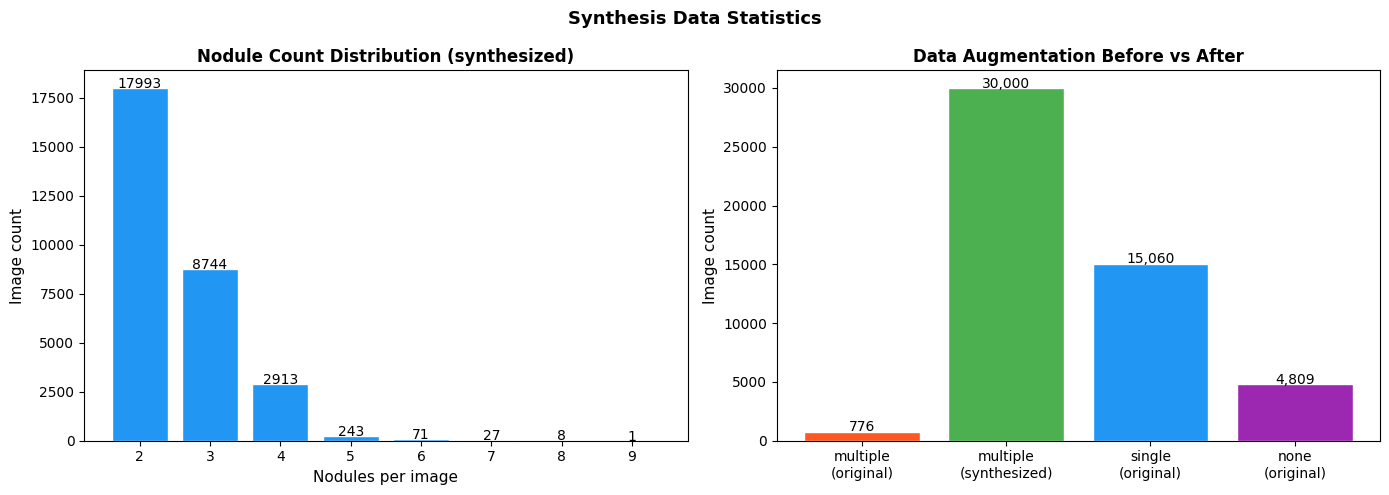

Multiple-nodule: 776 -> 30776


In [47]:
# Nodule count distribution
from collections import Counter as Ctr
nc_dist = Ctr(nodule_dist)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Synthesis Data Statistics', fontsize=13, fontweight='bold')

# Nodule count per image
ax = axes[0]
ks = sorted(nc_dist.keys())
vs = [nc_dist[k] for k in ks]
bars = ax.bar([str(k) for k in ks], vs, color='#2196F3', edgecolor='white')
for bar, v in zip(bars, vs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{v}', ha='center', fontsize=10)
ax.set_xlabel('Nodules per image', fontsize=11)
ax.set_ylabel('Image count', fontsize=11)
ax.set_title('Nodule Count Distribution (synthesized)', fontweight='bold')

# Before vs after
ax = axes[1]
categories = ['multiple\n(original)', 'multiple\n(synthesized)', 'single\n(original)', 'none\n(original)']
values = [
    type_counts.get('multiple', 0),
    success_count,
    type_counts.get('single', 0),
    type_counts.get('none', 0)
]
bar_colors = ['#FF5722', '#4CAF50', '#2196F3', '#9C27B0']
bars = ax.bar(categories, values, color=bar_colors, edgecolor='white')
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{v:,}', ha='center', fontsize=10)
ax.set_ylabel('Image count', fontsize=11)
ax.set_title('Data Augmentation Before vs After', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Multiple-nodule: {type_counts.get("multiple", 0)} -> {type_counts.get("multiple", 0) + success_count}')

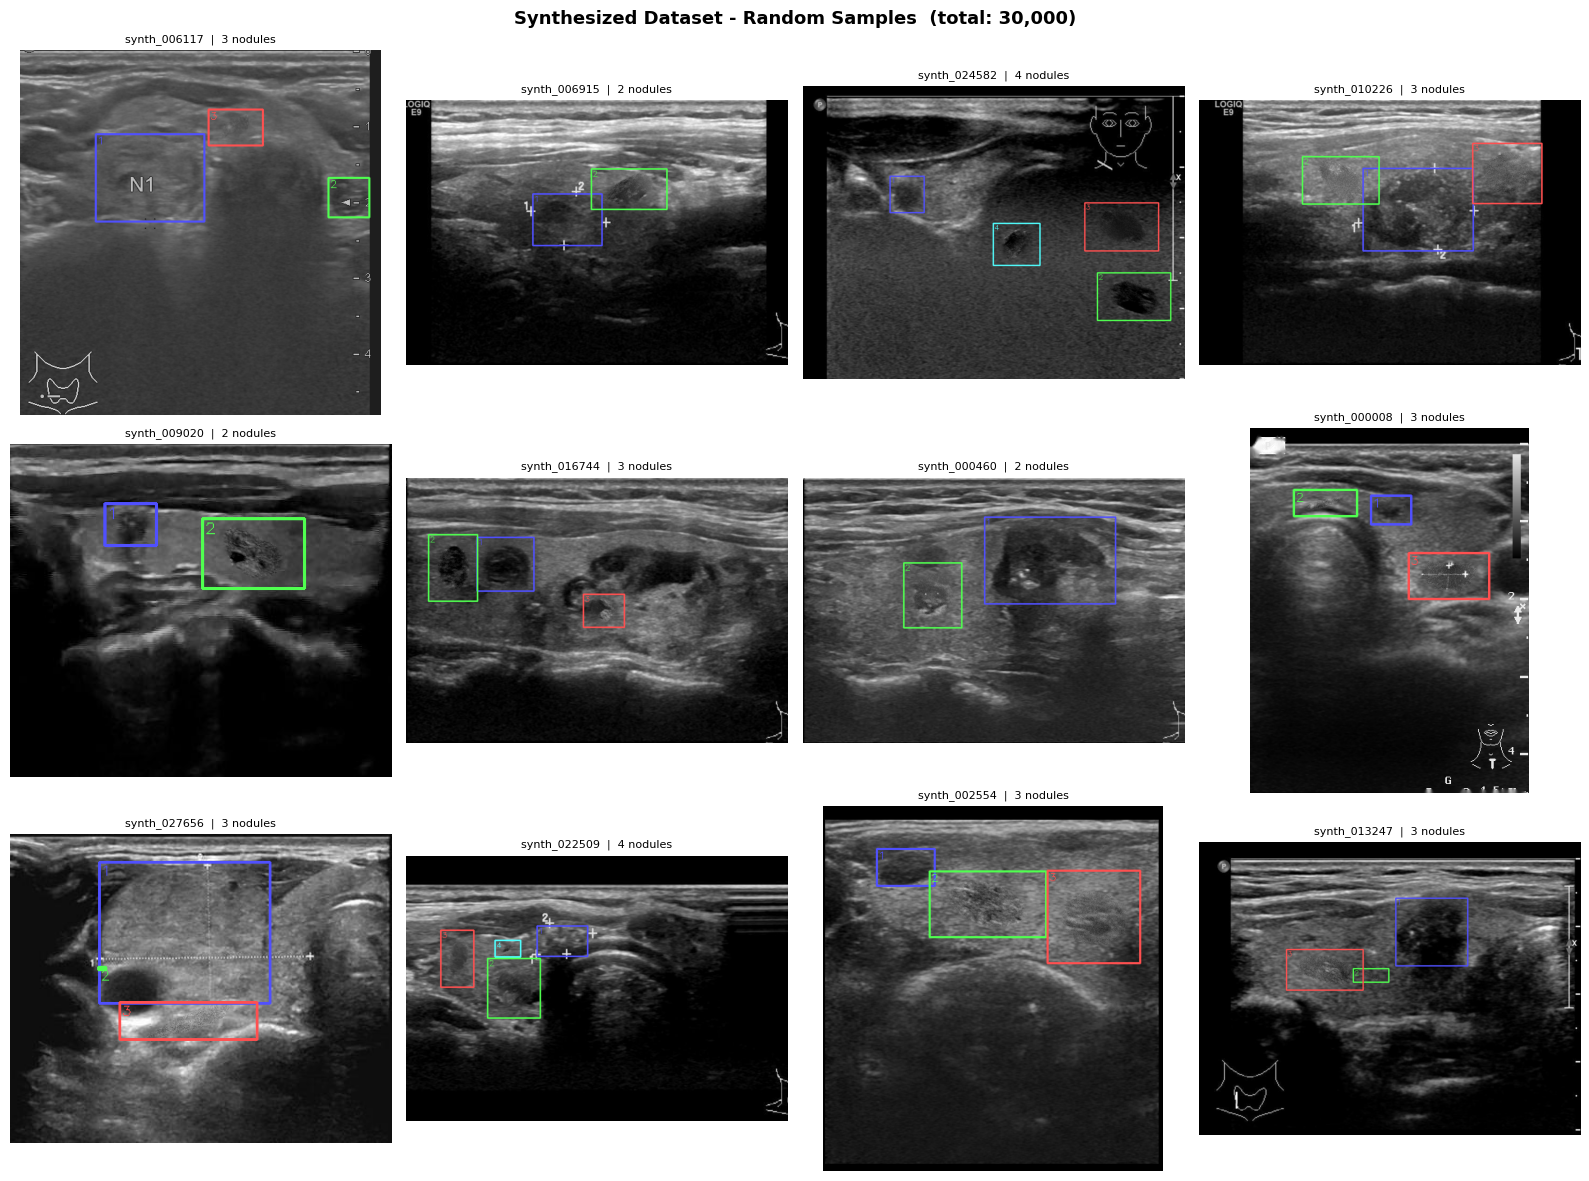

Each color represents a different nodule; number = nodule index


In [48]:
# Random sample grid from synthesized dataset
synth_imgs  = sorted((OUT_DIR / 'images').glob('*.png'))
synth_lbls  = sorted((OUT_DIR / 'labels').glob('*.txt'))
n_show_grid = 12

sample_idx = random.sample(range(len(synth_imgs)), min(n_show_grid, len(synth_imgs)))

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle(f'Synthesized Dataset - Random Samples  (total: {len(synth_imgs):,})', fontsize=13, fontweight='bold')

BOX_COLORS = [(255, 80, 80), (80, 255, 80), (80, 80, 255), (255, 255, 80), (255, 80, 255)]

for ax, si in zip(axes.flat, sample_idx):
    img    = cv2.imread(str(synth_imgs[si]), cv2.IMREAD_GRAYSCALE)
    ih, iw = img.shape
    lbls   = load_yolo_labels(synth_lbls[si])

    disp = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    for bi, b in enumerate(lbls):
        x1, y1, x2, y2 = yolo_to_pixel(b, iw, ih)
        color = BOX_COLORS[bi % len(BOX_COLORS)]
        cv2.rectangle(disp, (x1, y1), (x2, y2), color, 2)
        cv2.putText(disp, str(bi+1), (x1+2, y1+14),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    ax.imshow(cv2.cvtColor(disp, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{synth_imgs[si].stem}  |  {len(lbls)} nodules', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()
print('Each color represents a different nodule; number = nodule index')

In [49]:
# Verify paste is visible: show original vs result vs zoomed diff
test_r  = random.choice([r for r in recipient_records if r['nodule_type'] == 'single'])
res     = generate_synthetic(test_r, donor_crops, (1,1), SCALE_RANGE)

if res is None:
    print('No valid placement found — re-run')
else:
    orig_img, _, added = cv2.imread(str(test_r['img_path']), cv2.IMREAD_GRAYSCALE), None, None
    orig_img  = cv2.imread(str(test_r['img_path']), cv2.IMREAD_GRAYSCALE)
    synth_img, _, added = res
    diff = np.abs(synth_img.astype(np.int16) - orig_img.astype(np.int16)).astype(np.uint8)

    x1, y1, x2, y2 = added[0]
    pad = 25
    zx1, zy1 = max(0, x1-pad), max(0, y1-pad)
    zx2, zy2 = min(synth_img.shape[1], x2+pad), min(synth_img.shape[0], y2+pad)

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    fig.suptitle('Paste Verification', fontsize=13, fontweight='bold')

    axes[0].imshow(orig_img, cmap='gray');   axes[0].set_title('Original');         axes[0].axis('off')
    axes[1].imshow(synth_img, cmap='gray');  axes[1].set_title('After paste');       axes[1].axis('off')
    axes[2].imshow(np.clip(diff*8, 0, 255), cmap='hot')
    axes[2].set_title('Pixel diff x8');      axes[2].axis('off')

    # Zoom
    axes[3].imshow(synth_img[zy1:zy2, zx1:zx2], cmap='gray')
    rect = patches.Rectangle((x1-zx1, y1-zy1), x2-x1, y2-y1,
                               linewidth=2, edgecolor='lime', facecolor='none')
    axes[3].add_patch(rect)
    axes[3].set_title('Zoom: pasted nodule (green bbox)'); axes[3].axis('off')

    plt.tight_layout()
    plt.show()
    print(f'Pixel diff — max: {diff.max()}, changed_px (>2): {(diff>2).sum()}')

No valid placement found — re-run


---
## Step 9: Build Full Combined Dataset

Assemble a complete dataset for training and evaluation:

| Split | Source |
|-------|--------|
| **train** | synthesized multi-nodule + original train (single + none + multiple) |
| **val / test** | original test set (all nodule types) |

In [50]:
from collections import Counter as Ctr

# ── Collect paths ────────────────────────────────────────────

# 1. Synthesized multi-nodule (train)
synth_paths = sorted(OUT_DIR / 'images' / p.name
                     for p in (OUT_DIR / 'images').glob('*.png'))

# 2. Original train images — filter by TARGET_DATASETS, exclude converted singles
orig_train_records_filtered = [
    r for r in metadata
    if r['train_or_test'] == 'train'
    and r['dataset'] in TARGET_DATASETS
    and str(r['img_path']) not in used_recipient_paths  # exclude consumed singles
]
orig_train_paths = [r['img_path'] for r in orig_train_records_filtered]

n_excluded = len([r for r in metadata
                  if r['train_or_test'] == 'train'
                  and r['dataset'] in TARGET_DATASETS]) - len(orig_train_records_filtered)

# 3. Original test images — filter by TARGET_DATASETS
orig_test_records = [
    r for r in metadata
    if r['train_or_test'] == 'test'
    and r['dataset'] in TARGET_DATASETS
]
orig_test_paths   = [r['img_path'] for r in orig_test_records]

# ── Summary ──────────────────────────────────────────────────
orig_train_type = Ctr(r['nodule_type'] for r in orig_train_records_filtered)
orig_test_type  = Ctr(r['nodule_type'] for r in orig_test_records)

print('=== Combined Dataset Summary ===')
print(f'  Target datasets: {sorted(TARGET_DATASETS)}')
print(f'  (Donor pool uses all datasets regardless of TARGET_DATASETS)')
print(f'\nTrain split:')
print(f'  synthesis (multi-nodule) : {len(synth_paths):,}')
print(f'  original single          : {orig_train_type["single"]:,}  (excluded {n_excluded:,} converted to multi)')
print(f'  original none            : {orig_train_type["none"]:,}')
print(f'  original multiple        : {orig_train_type["multiple"]:,}')
print(f'  ─────────────────────────────')
total_train = len(synth_paths) + len(orig_train_paths)
print(f'  Total train              : {total_train:,}')

print(f'\nTest / Val split:')
print(f'  original single          : {orig_test_type["single"]:,}')
print(f'  original none            : {orig_test_type["none"]:,}')
print(f'  original multiple        : {orig_test_type["multiple"]:,}')
print(f'  ─────────────────────────────')
print(f'  Total test               : {len(orig_test_paths):,}')

=== Combined Dataset Summary ===
  Target datasets: ['CG', 'TN3K', 'TN5000']
  (Donor pool uses all datasets regardless of TARGET_DATASETS)

Train split:
  synthesis (multi-nodule) : 30,000
  original single          : 4,112  (excluded 7,569 converted to multi)
  original none            : 3,889
  original multiple        : 597
  ─────────────────────────────
  Total train              : 38,598

Test / Val split:
  original single          : 3,379
  original none            : 920
  original multiple        : 179
  ─────────────────────────────
  Total test               : 4,478


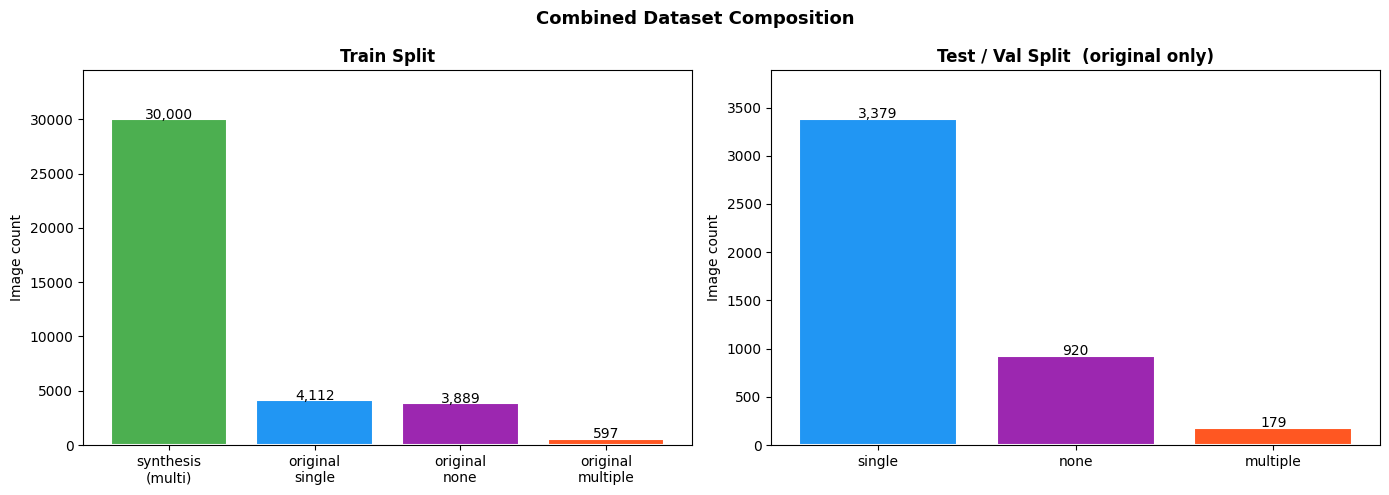

In [51]:
# Visualize combined dataset composition
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Combined Dataset Composition', fontsize=13, fontweight='bold')

# Train breakdown
ax = axes[0]
train_labels = ['synthesis\n(multi)', 'original\nsingle', 'original\nnone', 'original\nmultiple']
train_values = [
    len(synth_paths),
    orig_train_type['single'],
    orig_train_type['none'],
    orig_train_type['multiple'],
]
train_colors = ['#4CAF50', '#2196F3', '#9C27B0', '#FF5722']
bars = ax.bar(train_labels, train_values, color=train_colors, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, train_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{v:,}', ha='center', fontsize=10)
ax.set_title('Train Split', fontweight='bold')
ax.set_ylabel('Image count')
ax.set_ylim(0, max(train_values) * 1.15)

# Test breakdown
ax = axes[1]
test_labels = ['single', 'none', 'multiple']
test_values = [orig_test_type['single'], orig_test_type['none'], orig_test_type['multiple']]
test_colors = ['#2196F3', '#9C27B0', '#FF5722']
bars = ax.bar(test_labels, test_values, color=test_colors, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, test_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{v:,}', ha='center', fontsize=10)
ax.set_title('Test / Val Split  (original only)', fontweight='bold')
ax.set_ylabel('Image count')
ax.set_ylim(0, max(test_values) * 1.15)

plt.tight_layout()
plt.show()

In [52]:
import datetime, shutil
version = "v6"
COMBINED_DIR = BASE_DIR / 'yolo_data' / f'combined_with_synthesis_od_{version}'

# Create folder structure
for split in ('train', 'val'):
    (COMBINED_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
    (COMBINED_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)

def copy_image_and_label(img_path, split, lbl_src_dir=None):
    """Copy image and its label into COMBINED_DIR/images|labels/split/."""
    img_path = Path(img_path)
    dst_img = COMBINED_DIR / 'images' / split / img_path.name
    shutil.copy2(img_path, dst_img)

    # Label sits next to image or in a sibling labels/ folder
    if lbl_src_dir:
        lbl_path = Path(lbl_src_dir) / img_path.with_suffix('.txt').name
    else:
        lbl_path = img_path.parent.parent / 'labels' / img_path.with_suffix('.txt').name

    dst_lbl = COMBINED_DIR / 'labels' / split / img_path.with_suffix('.txt').name
    if lbl_path.exists():
        shutil.copy2(lbl_path, dst_lbl)
    else:
        # Write empty label file if not found
        dst_lbl.write_text('')

# ── Copy train data ──────────────────────────────────────────
print('Copying train images...')

# 1. Synthesized multi-nodule
for p in tqdm(synth_paths, desc='  synthesis'):
    lbl = OUT_DIR / 'labels' / p.with_suffix('.txt').name
    shutil.copy2(p,   COMBINED_DIR / 'images' / 'train' / p.name)
    shutil.copy2(lbl, COMBINED_DIR / 'labels' / 'train' / p.with_suffix('.txt').name)

# 2. Original train (filtered)
for r in tqdm(orig_train_records_filtered, desc='  original train'):
    copy_image_and_label(r['img_path'], 'train')

# ── Copy val data ────────────────────────────────────────────
print('Copying val images...')
for r in tqdm(orig_test_records, desc='  original val'):
    copy_image_and_label(r['img_path'], 'val')

# ── Write train.txt / val.txt (relative paths) ──────────────
train_imgs = sorted((COMBINED_DIR / 'images' / 'train').glob('*.png'))
val_imgs   = sorted((COMBINED_DIR / 'images' / 'val').glob('*.png'))

with open(COMBINED_DIR / 'train.txt', 'w') as f:
    for p in train_imgs:
        f.write(str(p) + '\n')

with open(COMBINED_DIR / 'val.txt', 'w') as f:
    for p in val_imgs:
        f.write(str(p) + '\n')

# ── data.yaml ────────────────────────────────────────────────
yaml_content = f"""# Combined OD dataset with synthesis
# Generated: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}
# Train: {len(train_imgs):,}  (synthesis + original single/none/multiple, consumed singles excluded)
# Val:   {len(val_imgs):,}   (original test set)

path: {COMBINED_DIR}
train: train.txt
val:   val.txt

names:
  0: nodule
  1: maybe_nodule

nc: 2
"""

with open(COMBINED_DIR / 'data.yaml', 'w') as f:
    f.write(yaml_content)

# ── Final size report ────────────────────────────────────────
def folder_size_mb(path):
    return sum(f.stat().st_size for f in Path(path).rglob('*') if f.is_file()) / 1024 / 1024

print(f'\nCombined dataset ready: {COMBINED_DIR}')
print(f'  images/train/ : {len(train_imgs):,} files')
print(f'  images/val/   : {len(val_imgs):,} files')
total_mb = folder_size_mb(COMBINED_DIR)
print(f'  Total size    : {total_mb:.1f} MB  ({total_mb/1024:.2f} GB)')
print()
print(yaml_content)

Copying train images...


  synthesis:   0%|          | 0/30000 [00:00<?, ?it/s]

  original train:   0%|          | 0/8598 [00:00<?, ?it/s]

Copying val images...


  original val:   0%|          | 0/4478 [00:00<?, ?it/s]


Combined dataset ready: /Users/tony.tu/Desktop/戴承智慧/thyroid/yolo_data/combined_with_synthesis_od_v6
  images/train/ : 38,598 files
  images/val/   : 4,478 files
  Total size    : 4101.9 MB  (4.01 GB)

# Combined OD dataset with synthesis
# Generated: 2026-04-08 11:13
# Train: 38,598  (synthesis + original single/none/multiple, consumed singles excluded)
# Val:   4,478   (original test set)

path: /Users/tony.tu/Desktop/戴承智慧/thyroid/yolo_data/combined_with_synthesis_od_v6
train: train.txt
val:   val.txt

names:
  0: nodule
  1: maybe_nodule

nc: 2



In [53]:
# ── Build multiple_val.txt — only Multiple nodule val images ─
multiple_val_records = [
    r for r in orig_test_records
    if r['nodule_type'] == 'multiple'
]

multiple_val_imgs = [
    COMBINED_DIR / 'images' / 'val' / Path(r['img_path']).name
    for r in multiple_val_records
    if (COMBINED_DIR / 'images' / 'val' / Path(r['img_path']).name).exists()
]
multiple_val_imgs = sorted(multiple_val_imgs)

multiple_val_txt = COMBINED_DIR / 'multiple_val.txt'
with open(multiple_val_txt, 'w') as f:
    for p in multiple_val_imgs:
        f.write(str(p) + '\n')

print(f'multiple_val.txt written: {multiple_val_txt}')
print(f'  Total multiple val images: {len(multiple_val_imgs):,}')


multiple_val.txt written: /Users/tony.tu/Desktop/戴承智慧/thyroid/yolo_data/combined_with_synthesis_od_v6/multiple_val.txt
  Total multiple val images: 179
